In [417]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout
from keras.layers import LSTM
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

In [418]:
Data_frame=pd.read_csv("Gold_price.csv")

In [419]:
Data_frame.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80",107.50K,0.01%
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20",105.99K,0.56%
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20",118.08K,-0.40%
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00",159.62K,0.74%
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55",NaN,0.30%


In [420]:
Data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2583 non-null   object
 1   Price     2583 non-null   object
 2   Open      2583 non-null   object
 3   High      2583 non-null   object
 4   Low       2583 non-null   object
 5   Vol.      2578 non-null   object
 6   Change %  2583 non-null   object
dtypes: object(7)
memory usage: 141.4+ KB


In [421]:
Data_frame.drop(['Vol.','Change %'],axis=1,inplace=True)

In [422]:
Data_frame

,Date,Price,Open,High,Low
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80"
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20"
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20"
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00"
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55"
...,...,...,...,...,...
2578,01/08/2013,"1,663.20","1,651.50","1,662.60","1,648.80"
2579,01/07/2013,"1,647.20","1,657.30","1,663.80","1,645.30"
2580,01/04/2013,"1,649.90","1,664.40","1,664.40","1,630.00"
2581,01/03/2013,"1,675.60","1,688.00","1,689.30","1,664.30"


# here we will not use the These feature and we need to drop this features from datset
# VOlume and Chnages % feature



In [423]:
Data_frame.head()

,Date,Price,Open,High,Low
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80"
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20"
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20"
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00"
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55"


In [424]:
Data_frame['Date']=pd.to_datetime(Data_frame['Date'])
Data_frame.sort_values(by='Date',ascending=True,inplace=True)
Data_frame.reset_index(drop=True,inplace=True)

In [425]:
Data_frame.head()

,Date,Price,Open,High,Low
0,2013-01-02,"1,689.90","1,675.80","1,695.00","1,672.10"
1,2013-01-03,"1,675.60","1,688.00","1,689.30","1,664.30"
2,2013-01-04,"1,649.90","1,664.40","1,664.40","1,630.00"
3,2013-01-07,"1,647.20","1,657.30","1,663.80","1,645.30"
4,2013-01-08,"1,663.20","1,651.50","1,662.60","1,648.80"


 we need to remove the , from dateset in price,high,low,open from Attributes


<!-- change the num value to float value -->



In [426]:
# Select all columns except 'Date'
numValues = Data_frame.drop('Date', axis=1).columns

# Remove commas and convert
for col in numValues:
    Data_frame[col] = Data_frame[col].str.replace(',', '').astype('float64')

In [427]:
Data_frame.head()

,Date,Price,Open,High,Low
0,2013-01-02,1689.9,1675.8,1695.0,1672.1
1,2013-01-03,1675.6,1688.0,1689.3,1664.3
2,2013-01-04,1649.9,1664.4,1664.4,1630.0
3,2013-01-07,1647.2,1657.3,1663.8,1645.3
4,2013-01-08,1663.2,1651.5,1662.6,1648.8


In [428]:
Data_frame.duplicated().sum()

np.int64(0)

In [429]:
Data_frame.isnull().sum().sum()  # ✅ Correct - lowercase 'n'

np.int64(0)

In [430]:
# Visualize the Gold price History data
figure = px.line(Data_frame, x='Date', y='Price')

# Update line color
figure.update_traces(line_color='black')  # Fixed: update_traces not update_treaces

# Update layout
figure.update_layout(
    xaxis_title='Date',
    yaxis_title='Scaled_Price',
    title={
        'text': 'Gold Price History',  # Fixed: use 'text' key
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    plot_bgcolor='rgba(255, 233, 0, 0.9)'  # Fixed: moved inside update_layout
)



In [431]:
test_size=Data_frame[Data_frame.Date.dt.year==2023].shape[0]
test_size

0

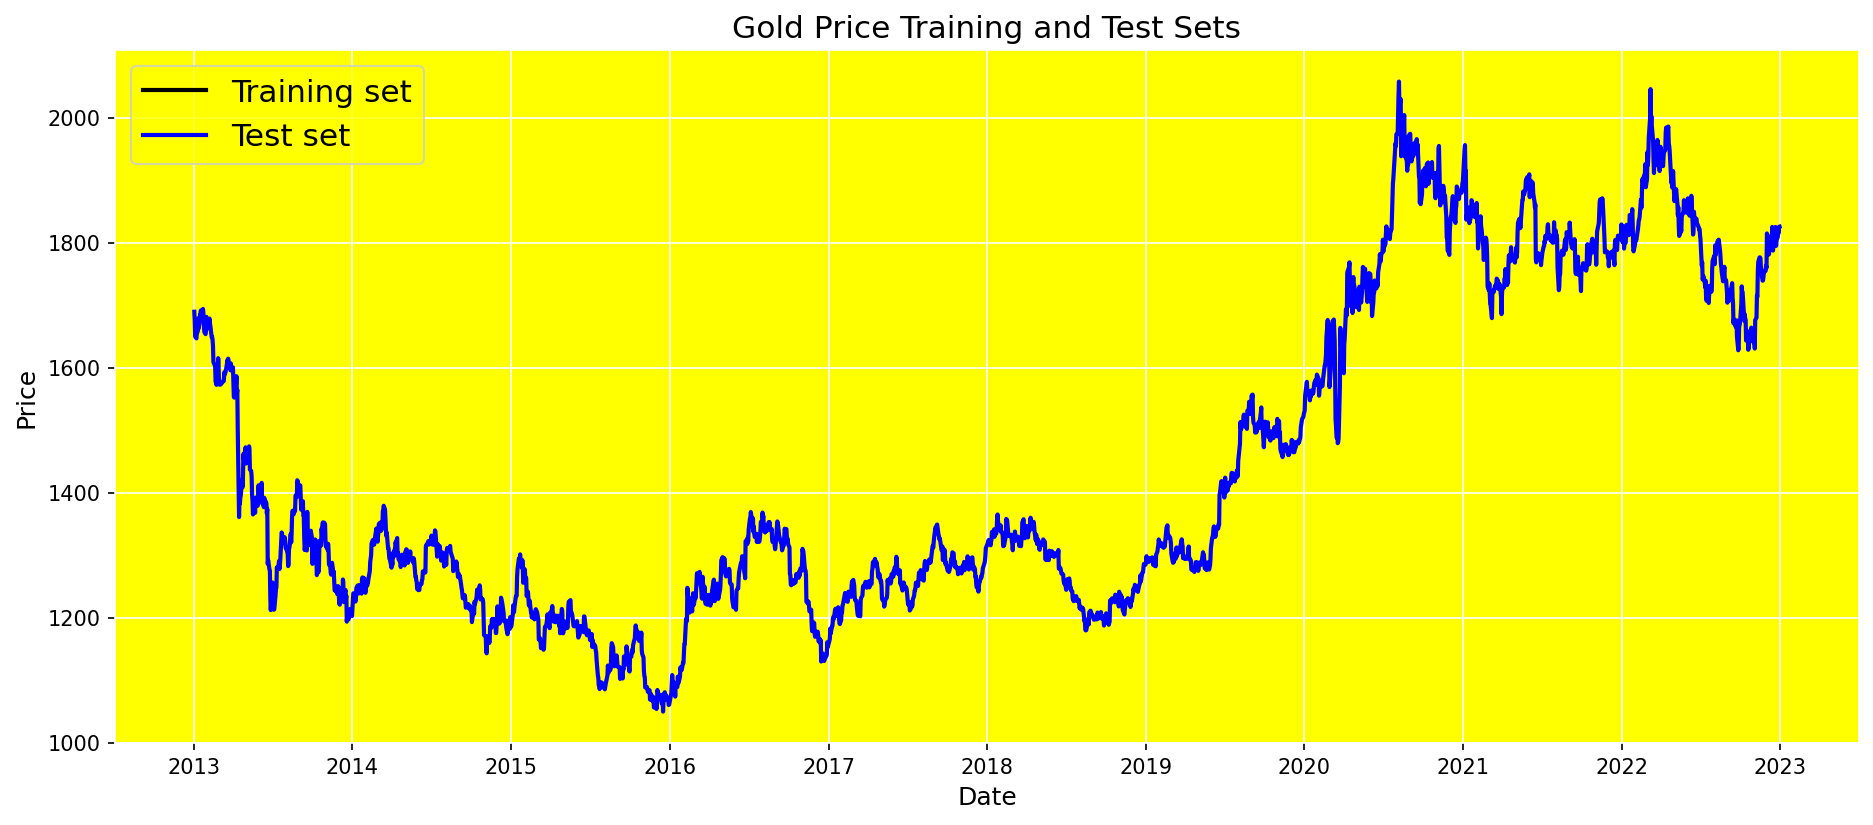

In [432]:
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes',edgecolor='white')
plt.plot(Data_frame.Date[:-test_size], Data_frame.Price[:-test_size], color='black', lw=2)
plt.plot(Data_frame.Date[-test_size:], Data_frame.Price[-test_size:], color='blue', lw=2)
plt.title('Gold Price Training and Test Sets', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(['Training set', 'Test set'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

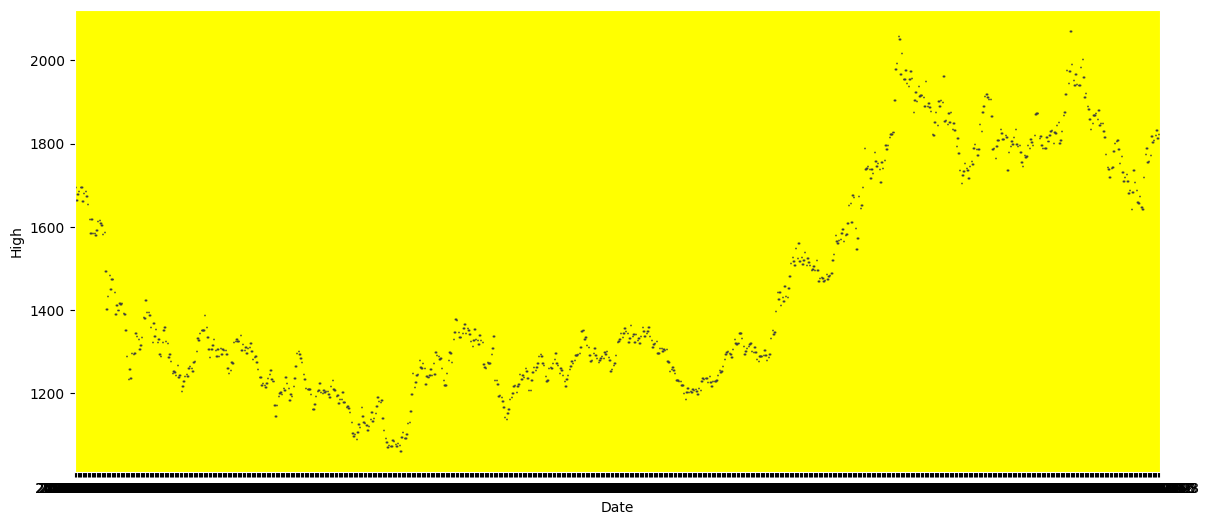

In [433]:
# Show every 5th date
Data_sampled = Data_frame.iloc[::3]
plt.figure(figsize=(14, 6))
sns.boxplot(x='Date', y='High', data=Data_sampled)
plt.show()

<Axes: >

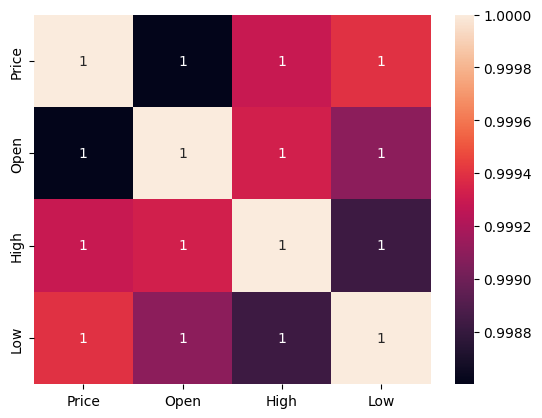

In [434]:
sns.heatmap(Data_frame.corr(numeric_only=True),annot=True)

In [435]:
# -------------------------
# TRAIN TEST SPLIT (80/20)
# -------------------------

test_size = int(len(Data_frame) * 0.2)

train_prices = Data_frame.Price[:-test_size]
test_prices  = Data_frame.Price[-test_size:]


In [436]:

Scaler = MinMaxScaler()
Scaler.fit(train_prices.values.reshape(-1,1))

train_data = Scaler.transform(train_prices.values.reshape(-1,1))
test_data  = Scaler.transform(test_prices.values.reshape(-1,1))

In [437]:

window_size = 50

X_train = []
y_train = []

for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

X_test = []
y_test = []

for i in range(window_size, len(test_data)):
    X_test.append(test_data[i-window_size:i, 0])
    y_test.append(test_data[i, 0])

In [438]:

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)


# -------------------------
# RESHAPE FOR LSTM
# -------------------------

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_train = y_train.reshape(-1,1)
y_test  = y_test.reshape(-1,1)

print('X_train Shape:', X_train.shape)
print('y_train Shape:', y_train.shape)
print('X_test Shape:', X_test.shape)
print('y_test Shape:', y_test.shape)

X_train Shape: (2017, 50, 1)
y_train Shape: (2017, 1)
X_test Shape: (466, 50, 1)
y_test Shape: (466, 1)


converting data into numpy arrays

<!-- create model LSTM Network -->

In [442]:

def define_model():
    input1 = Input(shape=(window_size, 1))

    x = LSTM(64, return_sequences=True)(input1)
    x = Dropout(0.2)(x)

    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.2)(x)

    x = LSTM(64)(x)
    x = Dropout(0.2)(x)

    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='linear')(x)

    model = Model(inputs=input1, outputs=output)
    model.compile(
        loss='mean_squared_error',
        optimizer='Nadam',
        metrics=['mae']
    )

    model.summary()
    return model

model = define_model()
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=30,
    validation_split=0.1,
    verbose=1
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,057 (332.25 KB)

 Trainable params: 85,057 (332.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.0058 - mae: 0.0504 - val_loss: 0.0041 - val_mae: 0.0483
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0017 - mae: 0.0317 - val_loss: 0.0086 - val_mae: 0.0826
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0014 - mae: 0.0288 - val_loss: 0.0170 - val_mae: 0.1239
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0013 - mae: 0.0274 - val_loss: 0.0021 - val_mae: 0.0343
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0012 - mae: 0.0259 - val_loss: 0.0057 - val_mae: 0.0656
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0011 - mae: 0.0246 - val_loss: 0.0020 - val_mae: 0.0339
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0010 - mae: 0.0240 - val_loss: 0.0029 - val_mae: 0.0449
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 9.3778e-04 - mae: 0.0224 - val_loss: 0.0020 - val_mae: 0.0348
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step 

In [443]:
result=model.evaluate(X_test, y_test)
y_pred=model.predict(X_test)

MAPE=mean_absolute_percentage_error(y_test,y_pred)
accuracy=1-MAPE
print("MAPE:",MAPE)
print("Test Loss:", result)
print("Accuracy:",accuracy)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.6917e-04 - mae: 0.0170
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
MAPE: 0.022330708980107455
Test Loss: [0.0004691662034019828, 0.017004400491714478]
Accuracy: 0.9776692910198925


In [444]:
y_test_true=Scaler.inverse_transform(y_test)
y_test_pred=Scaler.inverse_transform(y_pred)

ValueError: x and y must have same first dimension, but have shapes (516,) and (466, 1)

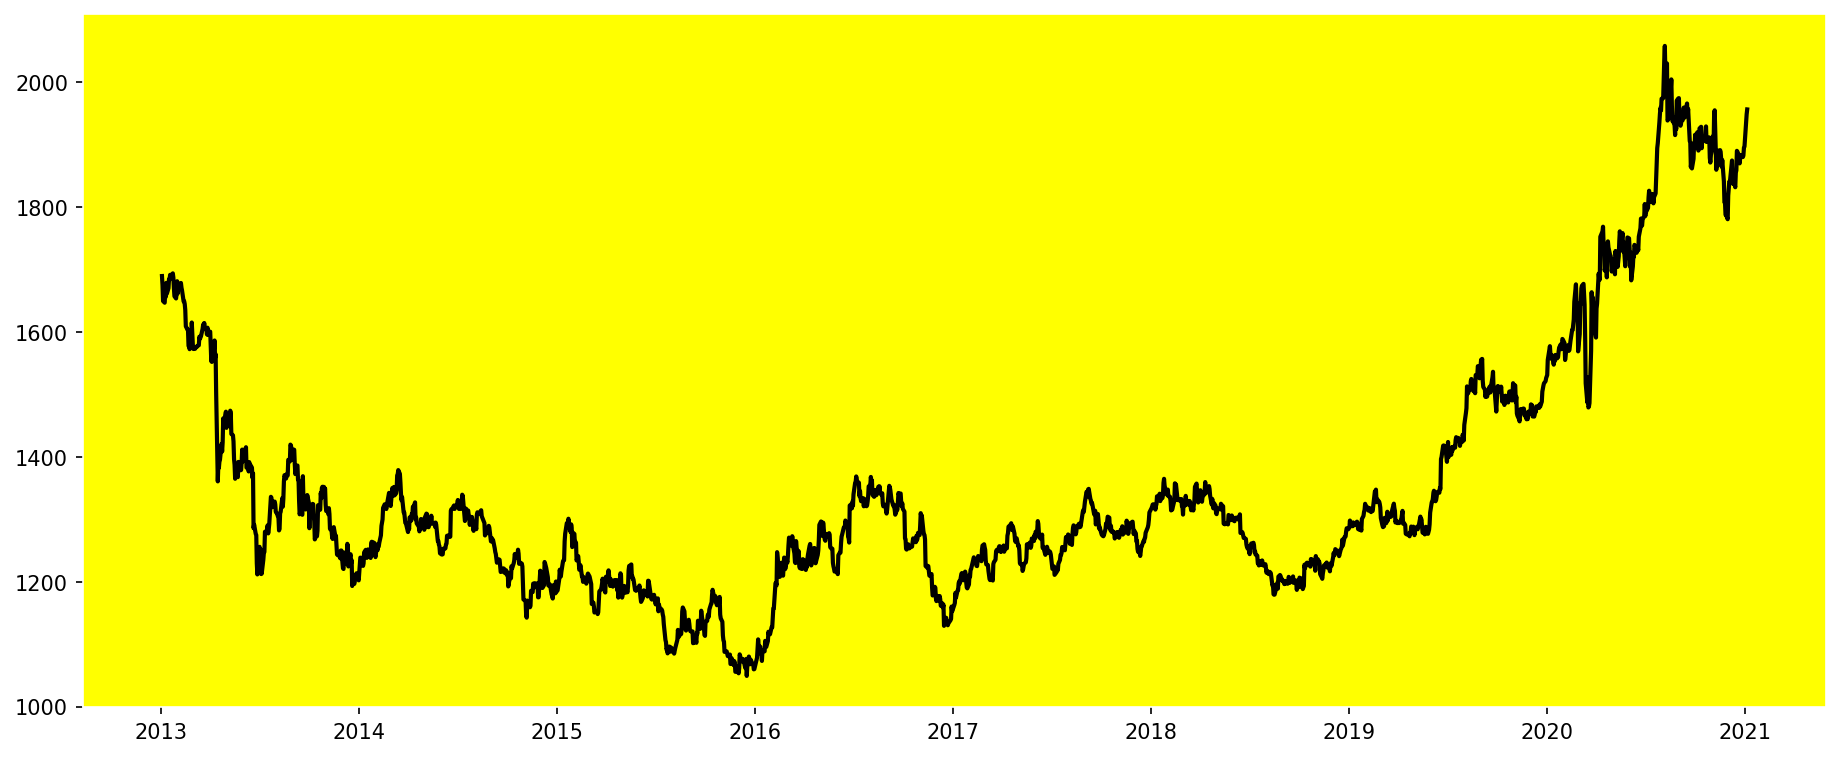

In [448]:
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'yellow'
plt.rc('axes',edgecolor='white')
plt.plot(Data_frame['Date'].iloc[:-test_size], Scaler.inverse_transform(train_data), color='black', lw=2)
plt.plot(Data_frame['Date'].iloc[-test_size:], y_test_true, color='blue', lw=2)
plt.plot(Data_frame['Date'].iloc[-test_size:], y_test_pred, color='red', lw=2)
plt.title('Model Performance on Gold Price Prediction', fontsize=15)
plt.xlabel('Date', fontsize=6)
plt.ylabel('Price', fontsize=6)
plt.legend(['Training Data', 'Actual Test Data', 'Predicted Test Data'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()